# **Eksperimen Preprocessing pada Dataset Deteksi Anomali Kartu Kredit**

**Nama:** Muhammad Muhibuddin Mukhlish  
**Proyek:** Proyek Akhir - Membangun Sistem Machine Learning

---

## Latar Belakang

Notebook ini merupakan bagian dari **Kriteria 1** proyek akhir, yaitu melakukan eksperimen pada dataset pelatihan. Tujuannya adalah untuk memahami, membersihkan, dan mempersiapkan data sebelum masuk ke tahap pemodelan.

### Informasi Dataset
Dataset yang digunakan adalah **"Credit Card Fraud Detection"** yang diperoleh dari Kaggle. Dataset ini berisi transaksi yang dilakukan oleh pemegang kartu kredit Eropa pada bulan September 2013.

Fitur-fitur dalam dataset ini adalah:
- **Time**: Detik yang telah berlalu antara setiap transaksi dan transaksi pertama dalam dataset.
- **Amount**: Jumlah uang transaksi.
- **V1-V28**: Fitur anonim yang merupakan hasil dari transformasi Principal Component Analysis (PCA) untuk melindungi privasi pengguna.
- **Class**: Variabel target, bernilai **1** jika transaksi adalah penipuan (fraud) dan **0** jika sebaliknya.

Tantangan utama dari dataset ini adalah **ketidakseimbangan kelas (class imbalance)** yang ekstrim, di mana jumlah transaksi fraud sangat sedikit dibandingkan transaksi normal.

# **1. Import Library**

Langkah pertama adalah mengimpor semua pustaka (library) Python yang akan kita gunakan untuk analisis dan prapemrosesan data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Mengatur agar output visualisasi dari matplotlib muncul di notebook
%matplotlib inline

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


# **2. Memuat Dataset**

Selanjutnya, kita akan memuat dataset `creditcard.csv` dari folder `dataset_raw` ke dalam sebuah DataFrame pandas. Kita juga akan menampilkan lima baris pertama untuk melakukan verifikasi awal.

In [2]:
# Path menuju file dataset mentah
data_path = '/kaggle/input/creditcardfraud/creditcard.csv'

# Membaca file CSV menjadi DataFrame
df = pd.read_csv(data_path)

# Menampilkan 5 baris pertama dari DataFrame
print("Dataset berhasil dimuat. Berikut adalah 5 baris pertama:")
df.head()

Dataset berhasil dimuat. Berikut adalah 5 baris pertama:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **3. Exploratory Data Analysis (EDA)**

EDA adalah proses investigasi awal pada data untuk menemukan pola, anomali, dan mendapatkan wawasan. Tahap ini sangat penting untuk menentukan langkah prapemrosesan yang tepat.

### 3.1. Informasi Dasar Dataset

Kita akan menggunakan `df.info()` untuk mendapatkan ringkasan singkat tentang DataFrame, termasuk jumlah baris, jumlah kolom, tipe data setiap kolom, dan jumlah nilai non-null. Ini berguna untuk mendeteksi nilai yang hilang (missing values) secara cepat.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 3.2. Statistik Deskriptif

Menggunakan `df.describe()` untuk melihat statistik dasar seperti rata-rata, standar deviasi, nilai minimum, maksimum, dan kuartil. Ini membantu kita memahami rentang dan distribusi dari setiap fitur numerik.

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.369007e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.500885e-15,-5.620335e-16,1.149614e-16,-2.426963e-15,...,1.596686e-16,-3.576577e-16,2.650499e-16,4.472317e-15,5.109395e-16,1.686100e-15,-3.662399e-16,-1.225457e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 3.3. Distribusi Kelas Target

Langkah krusial dalam masalah klasifikasi adalah memeriksa distribusi variabel target (`Class`). Ini akan menunjukkan apakah dataset kita seimbang atau tidak.

Distribusi Kelas:
Class
0    284315
1       492
Name: count, dtype: int64

Persentase kelas Fraud: 0.1727%


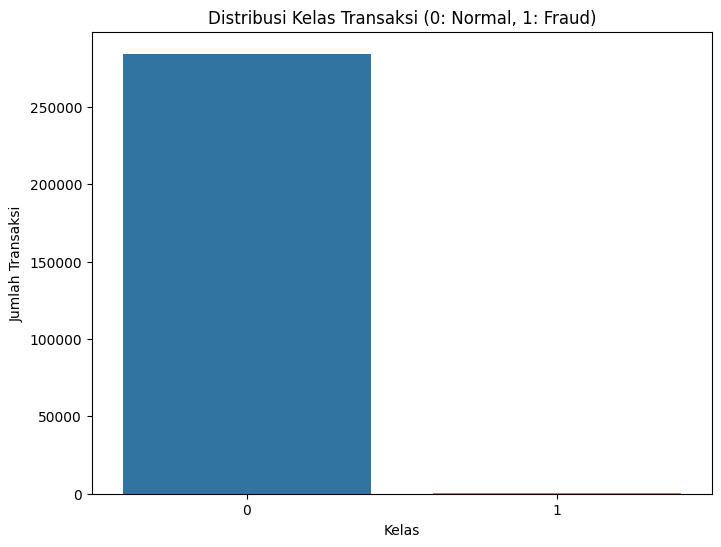

In [5]:
# Menghitung jumlah setiap kelas
class_counts = df['Class'].value_counts()
print("Distribusi Kelas:")
print(class_counts)

print(f"\nPersentase kelas Fraud: {round(class_counts[1] / len(df) * 100, 4)}%")

# Visualisasi distribusi kelas
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Distribusi Kelas Transaksi (0: Normal, 1: Fraud)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Transaksi')
plt.show()

## 4. Data Preprocessing

Berdasarkan temuan dari EDA, satu-satunya langkah prapemrosesan yang perlu kita lakukan pada dataset ini adalah **Feature Scaling** pada kolom `Time` dan `Amount` agar memiliki skala yang sama dengan fitur V1-V28. Kita akan menggunakan `StandardScaler` dari Scikit-learn.

In [6]:
# Membuat salinan DataFrame untuk menghindari perubahan pada data asli
df_processed = df.copy()

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Melakukan scaling pada kolom 'Amount' dan 'Time'
df_processed['scaled_amount'] = scaler.fit_transform(df_processed['Amount'].values.reshape(-1, 1))
df_processed['scaled_time'] = scaler.fit_transform(df_processed['Time'].values.reshape(-1, 1))

# Menghapus kolom 'Time' dan 'Amount' yang asli
df_processed = df_processed.drop(['Time', 'Amount'], axis=1)

print("Prapemrosesan selesai. Kolom 'Time' dan 'Amount' telah di-scaling.")

# Menampilkan 5 baris pertama dari data yang telah diproses
print("Berikut adalah 5 baris pertama dari data yang telah diproses:")
df_processed.head()

Prapemrosesan selesai. Kolom 'Time' dan 'Amount' telah di-scaling.
Berikut adalah 5 baris pertama dari data yang telah diproses:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541
